In [1]:
import xgboost as xgb 
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import mlflow
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, auc

c:\Users\pc\Desktop\Fraud Detection project\Fraud_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_train = pl.read_parquet("../Data/Processed/train_ready.parquet")
X = df_train.drop("isFraud")
y = df_train.select("isFraud")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    )
high_card_cols = [
    "DeviceInfo", "id_30", "id_31", "id_33",
    "P_emaildomain", "R_emaildomain"
]


for col in high_card_cols:
    # Compute frequency map from training set only
    freq_map = (
        X_train.get_column(col)
        .value_counts()
        .rename({"count": f"{col}_freq"})
    )
    
    # Join frequencies onto train and test
    X_train = X_train.join(freq_map, on=col, how="left").drop(col).rename({f"{col}_freq": col})
    X_test  = X_test.join(freq_map, on=col, how="left").drop(col).rename({f"{col}_freq": col})
    
    # Unseen test values get frequency 0
    X_test = X_test.with_columns(pl.col(col).fill_null(0))

dtrain = xgb.DMatrix(
    data=X_train.to_arrow(), 
    label=y_train.to_arrow(),
    enable_categorical=True
    )


dtest = xgb.DMatrix(
    data=X_test.to_arrow(),
    label=y_test.to_arrow(),
    enable_categorical=True
)

In [3]:
# 1. Initialize MLflow
mlflow.set_experiment("Fraud_Detection_Baseline")
mlflow.xgboost.autolog() # Automatically logs parameters, metrics, and the model


params = {
    "objective": "binary:logistic",
    "tree_method": "hist",
    "eval_metric": "aucpr"
}
with mlflow.start_run(run_name="Vanilla_Baseline_model"):
    # data paths used
    mlflow.log_param("train_data_path and test_data_path used after spliting", "../Data/Processed/train_ready.parquet")
    # Log the literal code file
    mlflow.log_artifact("Model_Experimentation.ipynb")
    # Optional: Log your DVC commit hash so you know exactly which data version was used
    mlflow.log_param("dvc_data_hash", "c56522775ad2f4b282cc385e82ee3302")

    training_history = {}


    baseline_model = xgb.train(
        params, 
        dtrain, 
        num_boost_round=200,        # Allow the model to build up to 200 trees
        evals= [(dtrain, "train"), (dtest, "test")],
        evals_result=training_history,    # Print the PR-AUC score live after every tree
        early_stopping_rounds=15    # Stop training automatically if test PR-AUC stops improving
    )

    predictions = baseline_model.predict(dtest)
    precision, recall, thresholds = precision_recall_curve(y_test.to_numpy(), predictions)
    final_pr_auc = auc(recall, precision)

    f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
    best_idx = np.argmax(f1_scores)

    optimal_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    best_precision = precision[best_idx]
    best_recall = recall[best_idx]

    # log metrics
    mlflow.log_metric("manual_test_pr_auc", final_pr_auc)
    mlflow.log_metric("optimal_threshold", optimal_threshold)
    mlflow.log_metric("precision_at_best_threshold", best_precision)
    mlflow.log_metric("recall_at_best_threshold", best_recall)
    mlflow.log_metric("f1_score_at_best_threshold", best_f1)

    mlflow.xgboost.log_model(
        xgb_model=baseline_model, 
        artifact_path="model",
        registered_model_name="Fraud_XGB_Model" # Registers it in the UI
    )

[0]	train-aucpr:0.39314	test-aucpr:0.39182
[1]	train-aucpr:0.46171	test-aucpr:0.45847
[2]	train-aucpr:0.48373	test-aucpr:0.47708
[3]	train-aucpr:0.50138	test-aucpr:0.49351
[4]	train-aucpr:0.51466	test-aucpr:0.50571
[5]	train-aucpr:0.52516	test-aucpr:0.51515
[6]	train-aucpr:0.53427	test-aucpr:0.52371
[7]	train-aucpr:0.54565	test-aucpr:0.53373
[8]	train-aucpr:0.55307	test-aucpr:0.54184
[9]	train-aucpr:0.57040	test-aucpr:0.55744
[10]	train-aucpr:0.58129	test-aucpr:0.56657
[11]	train-aucpr:0.58752	test-aucpr:0.57255
[12]	train-aucpr:0.59587	test-aucpr:0.57956
[13]	train-aucpr:0.60122	test-aucpr:0.58255
[14]	train-aucpr:0.60599	test-aucpr:0.58667
[15]	train-aucpr:0.61738	test-aucpr:0.59689
[16]	train-aucpr:0.62220	test-aucpr:0.60132
[17]	train-aucpr:0.62915	test-aucpr:0.60586
[18]	train-aucpr:0.63424	test-aucpr:0.60983
[19]	train-aucpr:0.63934	test-aucpr:0.61412
[20]	train-aucpr:0.64432	test-aucpr:0.61794
[21]	train-aucpr:0.64686	test-aucpr:0.61973
[22]	train-aucpr:0.64987	test-aucpr:0.6216

2026/09/09 21:31:09 WARNING mlflow.xgboost: Failed to infer model signature: could not sample data to infer model signature: please ensure that autologging is enabled before constructing the dataset.
2026/09/09 21:31:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/09 21:31:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Successfully registered model 'Fraud_XGB_Model'.
Created version '1' of model 'Fraud_XGB_Model'.


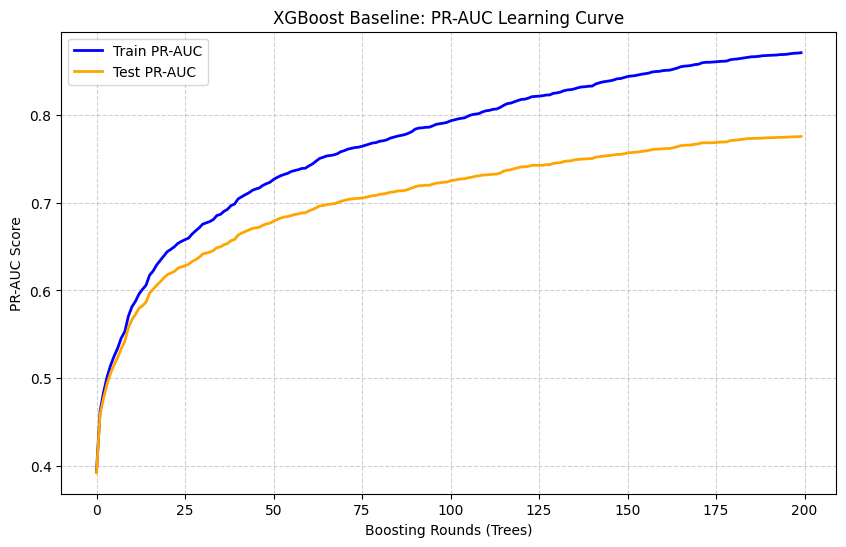

In [4]:
train_scores = training_history["train"]["aucpr"]
test_scores = training_history["test"]["aucpr"]
epochs = range(len(train_scores))

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_scores, label="Train PR-AUC", color="blue", linewidth=2)
plt.plot(epochs, test_scores, label="Test PR-AUC", color="orange", linewidth=2)

plt.title("XGBoost Baseline: PR-AUC Learning Curve")
plt.xlabel("Boosting Rounds (Trees)")
plt.ylabel("PR-AUC Score")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()